In [1]:
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer
import torch
import os
from pathlib import Path
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm
from astra.misc import transfer_to_device
from astra.proximals import AdamProxy
from astra.data.llm import get_c4
import numpy as np
os.environ["HF_HOME"]

'/buckets/datasets/huggingface'

In [97]:
class FP32Optimizer:
    """Optimizer wrapper: bf16 model, fp32 grad accumulation/states/step.

    Each backward() fires a hook that upcasts the bf16 grad to fp32 and
    adds it to an internal accumulator, then clears the bf16 grad so the
    next backward starts fresh -- no lossy bf16-on-bf16 accumulation.
    """

    def __init__(self, optimizer_cls, params, accum_steps=1, **kwargs):
        all_params = [p for p in params if p.requires_grad]
        self.bf16_params = all_params
        self.fp32_params = [
            p.detach().float().clone().requires_grad_(True) for p in all_params
        ]
        self._id_to_fp32 = {
            id(bp): fp for bp, fp in zip(self.bf16_params, self.fp32_params)
        }
        self.optimizer = optimizer_cls(self.fp32_params, **kwargs)
        self.accum_steps = accum_steps

        # fp32 gradient accumulators + hooks
        self._fp32_grads = [torch.zeros_like(fp) for fp in self.fp32_params]
        self._hooks = []
        for i, bp in enumerate(self.bf16_params):
            h = bp.register_post_accumulate_grad_hook(self._make_hook(i))
            self._hooks.append(h)

    def _make_hook(self, idx):
        def hook(param):
            if param.grad is not None:
                self._fp32_grads[idx].add_(param.grad.float())
                param.grad = None

        return hook

    def fp32_of(self, param):
        """Return the fp32 copy of a bf16 model parameter."""
        return self._id_to_fp32[id(param)]

    def zero_grad(self):
        for g in self._fp32_grads:
            g.zero_()
        for bp in self.bf16_params:
            bp.grad = None

    def step(self,copy_params=True):
        """Copy accumulated fp32 grads (averaged) to fp32 params, step, sync."""
        scale = 1.0 / self.accum_steps
        for fp, g in zip(self.fp32_params, self._fp32_grads):
            fp.grad = g * scale
        self.optimizer.step()

        if copy_params:
            self.sync_fp32_to_bf16()

        self.zero_grad()

    def sync_fp32_to_bf16(self):
        for bp, fp in zip(self.bf16_params, self.fp32_params):
            bp.data.copy_(fp.data)
    def sync_bf16_to_fp32(self):
        """Call after external in-place edits to bf16 params (e.g. proximal step)."""
        for bp, fp in zip(self.bf16_params, self.fp32_params):
            fp.data.copy_(bp.data)

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks.clear()

In [3]:
torch.backends.cuda.enable_flash_sdp(True)

In [4]:
# model_name = "HuggingFaceTB/SmolLM3-3B"
# model_name = "Qwen/Qwen3-1.7B"
# model_name = "Qwen/Qwen3-4B"
model_name = "Qwen/Qwen3-8B"

In [5]:
teacher = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    device_map="auto",
)

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

In [6]:
print(teacher.model.embed_tokens.weight.numel()/1000**2)
print(sum(p.numel() for n,p in teacher.model.named_parameters() if "self_attn" in  n)/1000**2)
print(sum(p.numel() for n,p in teacher.model.named_parameters() if "mlp" in  n)/1000**2)
print(teacher.lm_head.weight.numel()/1000**2)

622.329856
1509.958656
5435.817984
622.329856


In [7]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [8]:
seq_length = 2048
num_samples = 1024

In [9]:
c4_data = get_c4(num_samples=num_samples,seq_len=seq_length,tokenizer=tokenizer, seed=42)

 10%|█         | 35896/356317 [00:31<04:37, 1153.77it/s]


Clipping samples to length 2048


100%|██████████| 1024/1024 [00:00<00:00, 56449.59it/s]


In [10]:
student = teacher

In [11]:
from astra.hooks import ModuleInputCatcher, ModuleOutputCatcher

In [12]:
input_catcher = ModuleInputCatcher(device=torch.device("cpu"))
output_catcher = ModuleOutputCatcher(device=torch.device("cpu"))

In [13]:
student

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 4096)
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (up_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (down_proj): Linear(in_features=12288, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((4096,), eps=1e-06)
        (post_attention_la

In [14]:
# prev_layers = list(range(1,2))
prev_layers = list(range(0))
# layer_idx = prev_layers[-1] + 1
layer_idx = 0
layer_name = f"decoder_{layer_idx}"
print(prev_layers, layer_idx, layer_name)


[] 0 decoder_0


In [15]:
teacher_layer = teacher.model.layers[layer_idx]
output_catcher.attach(teacher_layer, layer_name)

In [16]:
tokenized_inputs = [{"input_ids": d[0]} for d in c4_data]

In [17]:
with torch.no_grad():
    for model_inputs in tqdm(tokenized_inputs):
        try:
            input_ids = model_inputs["input_ids"].to(teacher.device)
            attention_mask = torch.ones_like(input_ids)
            _ = teacher(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=None,
                use_cache=False,
            )
        except:
            pass

100%|██████████| 1024/1024 [10:49<00:00,  1.58it/s]


In [18]:
layer_targets = output_catcher.outputs[layer_name]

In [19]:
output_catcher.detach(layer_name)

In [20]:
student_layer = student.model.layers[layer_idx]

In [21]:
if False:
    for prev_l in prev_layers:
        layer_ckpt_path = Path(f"/buckets/checkpoints/{model_name}_decoder_{prev_l}.cpt")
        print(layer_ckpt_path)
        student.model.layers[prev_l].load_state_dict(torch.load(layer_ckpt_path))

In [22]:
# teacher.seq_len

In [23]:
input_catcher.attach(student_layer,layer_name)

In [24]:
# student_layer.load_state_dict(teacher_layer.state_dict())

In [25]:

with torch.no_grad():
    for model_inputs in tqdm(tokenized_inputs):
        try:
            input_ids = model_inputs["input_ids"].to(teacher.device)
            attention_mask = torch.ones_like(input_ids)

            _ = student(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=None,
                use_cache=False,
            )
        except: 
            pass

    # _  = teacher(**model_inputs.to(teacher.device), labels=None, use_cache=False)
    # _  = student(**model_inputs.to(teacher.device), labels=None, use_cache=False)
    
    # layer_inputs.append(iocatcher.inputs["layer_0"])
    # layer_outputs.append(iocatcher.outputs["layer_0"])

100%|██████████| 1024/1024 [10:51<00:00,  1.57it/s]


In [26]:
layer_inputs = input_catcher.inputs[layer_name]
# layer_targets = output_catcher.outputs[layer_name]

In [27]:
input_catcher.detach(layer_name)

In [28]:
# del(teacher)
torch.cuda.empty_cache()

In [29]:
# student.model.layers[layer_idx].load_state_dict(teacher.model.layers[layer_idx].state_dict())

In [30]:
# from deepspeed.ops.adam import DeepSpeedCPUAdam

In [31]:
# optimizer = DeepSpeedCPUAdam(model.parameters(),lr=1e-4, adamw_mode=False, weight_decay=1e-4)

In [32]:
# import deepspeed

In [33]:

# ds_config = {
#     "train_batch_size": 2,
#     "gradient_accumulation_steps": 2,
#     # "optimizer": {
#     #     "type": "DeepSpeedCPUAdam",
#     #     "params": {
#     #         "lr": 1e-4,
#     #         "adamw_mode": False,
#     #         "weight_decay": 1e-4
#     #     }
#     # },
#     "zero_optimization": {
#         "stage": 2,          # or 3
#         "offload_optimizer": {
#             "device": "cpu", # optimizer step is done on CPU
#             "pin_memory": True
#         }
#     }
# }

# model_engine, optimizer, _, _ = deepspeed.initialize(
#     model=model,
#     # model_parameters=model.parameters(),
#     config=ds_config,
#     optimizer=optimizer,
# )

In [34]:
# outs = model_engine(**model_inputs)

In [35]:
# model_engine.step()

In [36]:
# network.device = list(network.parameters())[0].device

In [37]:
# idx=0
# model_inputs = transfer_to_device(layer_inputs[idx], network.device)
# target = transfer_to_device(layer_targets[idx],network.device)

In [38]:
# model_inputs.device = network.device

In [39]:
# network.self_attn.config._attn_implementation

In [40]:
# network.self_attn.config._attn_implementation="eager"

In [41]:
network = student_layer

In [42]:
network

Qwen3DecoderLayer(
  (self_attn): Qwen3Attention(
    (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
    (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
    (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
    (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
    (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
    (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
  )
  (mlp): Qwen3MLP(
    (gate_proj): Linear(in_features=4096, out_features=12288, bias=False)
    (up_proj): Linear(in_features=4096, out_features=12288, bias=False)
    (down_proj): Linear(in_features=12288, out_features=4096, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): Qwen3RMSNorm((4096,), eps=1e-06)
  (post_attention_layernorm): Qwen3RMSNorm((4096,), eps=1e-06)
)

In [43]:
from torch import nn
target_class = [nn.Linear]

In [44]:
for p in network.parameters():
    p.requires_grad=False
for name, module in network.named_modules():
    if isinstance(module, tuple(target_class)):
        print(name, module)
        for p in module.parameters():
            p.requires_grad=True

self_attn.q_proj Linear(in_features=4096, out_features=4096, bias=False)
self_attn.k_proj Linear(in_features=4096, out_features=1024, bias=False)
self_attn.v_proj Linear(in_features=4096, out_features=1024, bias=False)
self_attn.o_proj Linear(in_features=4096, out_features=4096, bias=False)
mlp.gate_proj Linear(in_features=4096, out_features=12288, bias=False)
mlp.up_proj Linear(in_features=4096, out_features=12288, bias=False)
mlp.down_proj Linear(in_features=12288, out_features=4096, bias=False)


In [45]:
from copy import deepcopy
original_weights = deepcopy(network.state_dict())

In [46]:
from torch.optim import Adam,AdamW

In [47]:
len(original_weights)

11

In [48]:
for n,p in network.named_parameters():
    print(n, torch.norm(p.data).item(), p.abs().mean().item(), p.requires_grad)

self_attn.q_proj.weight 106.5 0.020263671875 True
self_attn.k_proj.weight 59.0 0.022705078125 True
self_attn.v_proj.weight 52.0 0.0201416015625 True
self_attn.o_proj.weight 101.5 0.0191650390625 True
self_attn.q_norm.weight 20.25 1.7109375 False
self_attn.k_norm.weight 42.25 2.15625 False
mlp.gate_proj.weight 181.0 0.0201416015625 True
mlp.up_proj.weight 170.0 0.01904296875 True
mlp.down_proj.weight 188.0 0.0208740234375 True
input_layernorm.weight 0.73046875 0.0113525390625 False
post_attention_layernorm.weight 7.875 0.12109375 False


In [49]:
# optimizer = Adam(network.parameters(), lr=1e-5, weight_decay=0.0, betas=(0.99,0.999))

In [50]:
# from spastra.models.layers import KLDiv
from torch import nn

In [51]:
# criterion = KLDiv()

In [52]:
criterion = nn.MSELoss()

In [53]:
from sparsekit.block import BlockSpec
# from sparsekit.blocks import BlockCoupling
from sparsekit.scope import ScopeSpec

In [54]:
for n,p in network.named_parameters():
    if p.requires_grad:
        print(n, p.shape, p.data.norm())

self_attn.q_proj.weight torch.Size([4096, 4096]) tensor(106.5000, device='cuda:0', dtype=torch.bfloat16)
self_attn.k_proj.weight torch.Size([1024, 4096]) tensor(59., device='cuda:0', dtype=torch.bfloat16)
self_attn.v_proj.weight torch.Size([1024, 4096]) tensor(52., device='cuda:0', dtype=torch.bfloat16)
self_attn.o_proj.weight torch.Size([4096, 4096]) tensor(101.5000, device='cuda:0', dtype=torch.bfloat16)
mlp.gate_proj.weight torch.Size([12288, 4096]) tensor(181., device='cuda:0', dtype=torch.bfloat16)
mlp.up_proj.weight torch.Size([12288, 4096]) tensor(170., device='cuda:0', dtype=torch.bfloat16)
mlp.down_proj.weight torch.Size([4096, 12288]) tensor(188., device='cuda:0', dtype=torch.bfloat16)


In [55]:
prune_layers = {}
for n,l in network.named_modules():
    if isinstance(l, nn.Linear): 
        if l.weight.requires_grad:
            print(n)
            prune_layers[n] = l

self_attn.q_proj
self_attn.k_proj
self_attn.v_proj
self_attn.o_proj
mlp.gate_proj
mlp.up_proj
mlp.down_proj


In [56]:
prune_layers

{'self_attn.q_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'self_attn.k_proj': Linear(in_features=4096, out_features=1024, bias=False),
 'self_attn.v_proj': Linear(in_features=4096, out_features=1024, bias=False),
 'self_attn.o_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'mlp.gate_proj': Linear(in_features=4096, out_features=12288, bias=False),
 'mlp.up_proj': Linear(in_features=4096, out_features=12288, bias=False),
 'mlp.down_proj': Linear(in_features=12288, out_features=4096, bias=False)}

In [132]:
groups = []
groups_nnz = []

In [133]:
head_dim = teacher.config.head_dim

In [134]:
# for n,p in network.self_attn.named_parameters():
# for layer_name, layer in prune_layers.items():
#     p = layer.weight    
#     print(layer_name, p.shape)
#     # groups.append(GroupSpec(BlockSpec(p, block_shape=(-1,1)), group_shape=(-1,), name=n))
#     groups.append(GroupSpec(BlockSpec(p, block_shape=(1,1)), group_shape=(1,4), name=layer_name))
    # groups.append(GroupSpec(BlockSpec(p, block_shape=(-1,1)), group_shape=(32,), name=n))

In [136]:
accum_steps = 1
threshold_lr = 6e-4
optimizer = FP32Optimizer(
    AdamW,
    student_layer.parameters(),
    accum_steps=accum_steps,
    lr=threshold_lr,
    weight_decay=8e-3,
    betas=(0.98, 0.99),
)
proxy = AdamProxy(optimizer.optimizer)

In [137]:
# for layer_name in ["self_attn.k_proj", "self_attn.v_proj"]:
for layer_name in prune_layers:
    blk = BlockSpec(optimizer._id_to_fp32[id(prune_layers[layer_name].weight)], shape=(1,1),  name=layer_name)
    groups.append(ScopeSpec(blk, shape=(1,4)))
    groups_nnz.append(2)

In [138]:
# optimizer._id_to_fp32[id(prune_layers[layer_name].weight)]

In [139]:
# q_block = BlockSpec(prune_layers["self_attn.q_proj"].weight, block_shape=(head_dim,-1), name="self_attn.q_proj")
# o_block = BlockSpec(prune_layers["self_attn.o_proj"].weight, block_shape=(-1,head_dim), name="self_attn.o_proj")
# qo_block = BlockCoupling([q_block, o_block], orders=[(0,),(0,)], name="self_attn.qo_proj")

In [140]:
# qo_block

In [141]:
# groups.append(GroupSpec(qo_block, group_shape=(-1,), name="self_attn.qo_proj"))
# groups_nnz.append(24)

In [142]:
# gate_block = BlockSpec(prune_layers["mlp.gate_proj"].weight, block_shape=(1,-1), name="mlp.gate_proj")
# up_block = BlockSpec(prune_layers["mlp.up_proj"].weight, block_shape=(1,-1), name="mlp.up_proj")
# down_block = BlockSpec(prune_layers["mlp.down_proj"].weight, block_shape=(-1,1), name="mlp.down_proj")
# mlp_block = BlockCoupling([gate_block, up_block, down_block], orders=[(0,),(0,),(0,)], name="mlp.proj")

In [143]:
# mlp_block

In [144]:
# groups.append(GroupSpec(mlp_block, group_shape=(-1,), name="mlp_group"))

In [145]:
# groups_nnz.append(int(mlp_block.num_blocks* 0.75))

In [146]:
groups

[ScopeSpec[block_shape=(1, 4), grid_shape=(4096, 1024), name=None], block=BlockSpec(shape=(1, 1), grid_shape=(4096, 4096), name='self_attn.q_proj'),
 ScopeSpec[block_shape=(1, 4), grid_shape=(1024, 1024), name=None], block=BlockSpec(shape=(1, 1), grid_shape=(1024, 4096), name='self_attn.k_proj'),
 ScopeSpec[block_shape=(1, 4), grid_shape=(1024, 1024), name=None], block=BlockSpec(shape=(1, 1), grid_shape=(1024, 4096), name='self_attn.v_proj'),
 ScopeSpec[block_shape=(1, 4), grid_shape=(4096, 1024), name=None], block=BlockSpec(shape=(1, 1), grid_shape=(4096, 4096), name='self_attn.o_proj'),
 ScopeSpec[block_shape=(1, 4), grid_shape=(12288, 1024), name=None], block=BlockSpec(shape=(1, 1), grid_shape=(12288, 4096), name='mlp.gate_proj'),
 ScopeSpec[block_shape=(1, 4), grid_shape=(12288, 1024), name=None], block=BlockSpec(shape=(1, 1), grid_shape=(12288, 4096), name='mlp.up_proj'),
 ScopeSpec[block_shape=(1, 4), grid_shape=(4096, 3072), name=None], block=BlockSpec(shape=(1, 1), grid_shape=(

In [147]:
groups_nnz

[2, 2, 2, 2, 2, 2, 2]

In [148]:
assert len(groups_nnz) == len(groups)

In [149]:
# for layer_name, layer in prune_layers.items():
#     if isinstance(layer, nn.Linear):
#         print(layer_name, layer)
#         input_catcher.attach(layer, layer_name)
#         output_catcher.attach(layer, layer_name)

In [150]:
network.device = list(network.parameters())[0].device

In [151]:
beta=0.98

In [152]:
# optimizer = AdamW(network.parameters(), lr=4e-5, weight_decay=1e-3, betas=(0.95,0.99))
# optimizer = Adam(network.parameters(), lr=1e-4,weight_decay=1e-3, betas=(0.95,0.999))

In [153]:
# from bonsainet.proximals import AdamProxy
# proxy = AdamProxy(optimizer)

In [154]:
# from bonsainet.proximals import AdamWProxy
# proxy = AdamWProxy(optimizer)

In [155]:
epochs = 1

In [156]:
network.device = list(network.parameters())[0].device

In [81]:
# for b,a in alphas.items():
    # alphas[b] = a.to(network.device)

In [82]:
with torch.no_grad():
    pbar = tqdm(range(len(layer_inputs)), desc=f"Eval initial loss")
    total_loss = 0.0
    total_target_norm2 = 0.0
    num_batches = 0
    for idx in pbar:
        model_inputs = transfer_to_device(layer_inputs[idx], network.device)
        target = transfer_to_device(layer_targets[idx],network.device)
        # target = transfer_to_device(layer_targets[idx],network.device)[0]
        num_batches += 1
        pred = network(
            *model_inputs["args"],
            **model_inputs["kwargs"]
        )
        if isinstance(pred, tuple):
            pred,target = pred[0], target[0]
        total_loss += criterion(pred, target).item()
        total_target_norm2 += criterion(torch.zeros_like(target), target).item()
        pbar.set_postfix(
            loss=f"{total_loss / num_batches:e}",
            mse=f"{total_target_norm2 / num_batches:e}",
            density=np.mean([g.nnz() / g.block.numblk() for g in groups]),
        )
        # print("Avg density", np.mean([g.nnz()/g.numel for g in groups]))
total_target_rmse = (total_target_norm2 / num_batches)**.5
print("Target rmse: ", total_target_rmse)

Eval initial loss: 100%|██████████| 1024/1024 [00:24<00:00, 41.86it/s, density=1, loss=0.000000e+00, mse=3.029144e-02]

Target rmse:  0.1740443567103575


In [123]:
torch.cuda.empty_cache()

In [84]:
# diag_estimator = DiagGNEstimator(network, store_full_diag=True, device=network.device)
# diag_estimator.start()

In [85]:
# diag_estimator.stop()

In [86]:
# epoch = 0
# pbar = tqdm(
#     np.random.permutation(len(layer_inputs)),
#     desc=f"Backward for GN Diag",
# )
# total_loss = 0.0
# num_batches = 0
# optimizer.zero_grad()
# for idx in pbar:
#     num_batches += 1

#     model_inputs = transfer_to_device(layer_inputs[idx], network.device)
#     target = transfer_to_device(layer_targets[idx], network.device)

#     pred = network(model_inputs["args"][0], **model_inputs["kwargs"])

#     optimizer.zero_grad()
#     loss = criterion(pred, target)
#     loss.backward()
#     total_loss += loss.item()
#     pbar.set_postfix(
#                 loss=f"{total_loss / num_batches:e}",
#             )

In [157]:
if False:
    warm_up_epochs = 2
    for epoch in range(warm_up_epochs):
        pbar = tqdm(range(len(layer_inputs)), desc=f"Epoch {epoch + 1}/{warm_up_epochs}")
        total_loss = 0.0
        num_batches = 0
        for idx in pbar:
            model_inputs = transfer_to_device(layer_inputs[idx], network.device)
            target = transfer_to_device(layer_targets[idx],network.device)
            num_batches += 1
            pred = network(model_inputs["args"][0], **model_inputs["kwargs"])
            # pred = pred.view(-1, pred.shape[-1])
            loss = criterion(pred, target)
            optimizer.zero_grad()
            loss.backward()
            clip_grad_norm_(network.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=f"{total_loss / num_batches:.6f}", density = np.mean([g.nnz()/g.numel for g in groups]))
            # with torch.no_grad():
                # print(max(p.grad.abs().max() for p in network.parameters() if p.requires_grad ))



        for n,p in network.named_parameters():
            if "proj" in n:
                print(n, ((p.data.abs()> 1e-12).sum()/p.numel()).item())
        # print("Avg density", np.mean([g.nnz()/g.numel for g in groups]))

In [158]:
# old_masks = {: torch.ones_like(g.block.param.data).bool() for g in groups}
old_masks = {}
for g,nnz in zip(groups, groups_nnz):
    old_masks.update(g.get_masks(nnz=nnz))

In [159]:
lambds = {g: torch.zeros_like(g.kth_largest(None,1)) for g in groups}

In [160]:
grad_accum_steps = 8

In [161]:
epochs = 10

In [162]:
alphas = {}

In [163]:
def normalize_conditioner(
    conditioner: torch.Tensor, min_val: float = 1e-6, max_val: float = 1e-4
) -> torch.Tensor:
    """
    Normalize conditioner values to [min_val, max_val] while preserving relative order.
    Uses log-space transformation to handle large dynamic ranges.

    Args:
        conditioner: Input tensor with potentially large dynamic range
        min_val: Minimum value of output range
        max_val: Maximum value of output range

    Returns:
        Normalized tensor with values in [min_val, max_val]
    """
    # Clamp to avoid log(0)
    cond_clamped = conditioner.clamp(min=1e-20)

    # Transform to log space to handle large dynamic range
    log_cond = torch.log(cond_clamped)

    # Get min/max in log space
    log_min = log_cond.min()
    log_max = log_cond.max()

    # Handle edge case where all values are the same
    if log_max - log_min < 1e-10:
        return torch.full_like(conditioner, (min_val + max_val) / 2)

    # Linear interpolation in log space, then map to target interval
    normalized = (log_cond - log_min) / (log_max - log_min)  # Now in [0, 1]
    result = min_val + normalized * (
        max_val - min_val
    )  # Now in [min_val, max_val]

    return result

In [164]:
masks = {}

In [165]:
for epoch in range(epochs):
    pbar = tqdm(
        np.random.permutation(len(layer_inputs)),
        desc=f"Epoch {epoch + 1}/{epochs}",
    )
    total_loss = 0.0
    num_batches = 0
    optimizer.zero_grad()

    for idx in pbar:
        num_batches += 1

        model_inputs = transfer_to_device(layer_inputs[idx], network.device)
        target = transfer_to_device(layer_targets[idx], network.device)

        pred = network(*model_inputs["args"], **model_inputs["kwargs"])
        if isinstance(pred, tuple):
            pred,target = pred[0], target[0]

        # target = transfer_to_device(layer_targets[idx],network.device)[0]
        # pred = network(
        #     model_inputs["args"][0],
        #       **model_inputs["kwargs"]
        # )[0]
        # pred = pred.view(-1, pred.shape[-1])
        loss = criterion(pred, target)
        loss.backward()
        # clip_grad_norm_(network.parameters(), max_norm=1.0)
        total_loss += loss.item()

        masks = {}
        if num_batches % grad_accum_steps == 0:
            optimizer.step(copy_params=False)
            optimizer.zero_grad()
            # diags = diag_estimator.get_diag()
            # for g_nnz, g in zip(groups_nnz, groups):
            #     conditioners = {}
            #     psis = {}
            #     # block = g.block
            #     # for 
            #     block_psis = {}
            #     conditioners = {}

            for g_nnz, g in zip(groups_nnz, groups):
                block = g.block

                gradient, lr, conditioner = proxy.get_info(
                    block.view.param
                    # optimizer.fp32_of(block.view.param)
                )

                data = block.view.param.data.clone()
                psi = gradient - conditioner * data
                vals = g.kth_mid({block: psi}, nnz=g_nnz,k_weight=1999.0)
                lambds[g].mul_(beta).add_((1 - beta) * vals)
                # vals.add_(g.kth_largest({block: psi}, nnz=g_nnz))
                # vals.mul_(0.5)
                g.soft_threshold(lambds[g] * lr, conditioners={block: conditioner})
                mask = g.get_masks(nnz=g_nnz)
                masks.update(mask)
                m = mask[block].float()
                block.view.param.data.copy_(data * m + (1 - m) * block.view.param.data)
                optimizer.sync_fp32_to_bf16()

                # for block in g.data:
                    # alphas[block]  = alphas.get(block,0)*0.9 + diags[block.name]*0.1
                    # if torch.any(torch.isnan(alphas[block])):
                    #     raise RuntimeError("NaN in alphas")

                    # gradient, lr, conditioner = proxy.get_info(block.param)
                    # psi = (gradient - alpha * block.param.data).abs()
                    # psi = (gradient - conditioner.sqrt() * block.param.data).abs()
                    # conds = alphas[block] 
                    # conds = conds / (conds.median()+1e-20)
                    # * 1e-2
                    # conds = conds.clamp(min=1e-4, max=1e-3)
                    # conds = torch.ones_like(cond) * 1e-o
                    # conditioner = conditioner / (conditioner.median()+1e-20)
                    # conditioner.clamp_(min=1e-4, max=1e-3)
                    # conditioners[block] = conditioner
                    # cond = (conditioner/ conditioner.median()).clamp(min=1e-5, max=1e-3)
                    # cond = normalize_conditioner(conditioner, min_val=4e-5, max_val=1e-4)

                    # psi = (gradient -  cond* block.param.data).abs()
                    # block_psis[block] = psi
                # psi_k = (
                #         g.kth_largest(block_psis, num_nz=g_nnz + 1)+
                #         g.kth_largest(block_psis, num_nz=g_nnz)
                #     ) / 2
                # lambds[g].mul_(beta).add_((1 - beta) * psi_k)
                # g.soft_threshold(lambds[g] * lr, conditioners={block: conditioner})
                # raise RuntimeError("Stop here")
                # data = block.param.data.clone()
                # datas = {block: block.param.data.clone() for block in g.data}
                # g.hard_threshold(num_nz=g_nnz, values=block_psis)
                # g.hard_threshold(values=block_psis, thresholds=lambds[g])
                # masks.update(g.get_masks(num_nz=g_nnz))
                # for block in g.data:
                #     block.param.data.copy_(datas[block])
                # block.param.data.copy_(data)
                # g.soft_threshold(
                #     lambds[g] * lr,
                #     conditioners=conditioners,
                #     max_iter=20,
                #     eps=1e-20,
                # )
                # for block in g.data:
                #     block.param.data.copy_(
                #     masks[block] * datas[block] + (~masks[block]) * block.param.data
                # )
                # masks.append(mask[block])

            # diag_estimator.diagW.clear()
            pbar.set_postfix(
                loss=f"{total_loss / num_batches:e}",
                rmse=f"{(total_loss / num_batches)**.5 / total_target_rmse:e}",
                density=np.mean([g.nnz(eps=1e-4) / g.block.numblk() for g in groups]),
                change=sum(
                    (masks[b] != old_masks[b]).sum().item()
                    for b in masks
                ),
                lambds=sum(lambds[g].mean().item() for g in groups)
                / len(groups),
                # quant=torch.quantile(block.block_norms().abs().float(),0.249).item()
            )
            old_masks = masks
        # break
    # break
    # if idx% 16 == 0:
    #     for n,p in network.named_parameters():
    #         if "proj" in n:
    #             print(n, ((p.data.abs()> 1e-12).sum()/p.numel()).item())

for n, p in network.named_parameters():
    if "proj" in n:
        print(n, (p.data.abs() > 1e-6).sum().item() / p.numel(), p.numel())
# print("Avg density", np.mean([g.nnz()/g.numel for g in groups]))

Epoch 1/10:   1%|          | 7/1024 [00:00<00:59, 17.13it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 192.00 MiB. GPU 0 has a total capacity of 23.56 GiB of which 127.00 MiB is free. Including non-PyTorch memory, this process has 23.36 GiB memory in use. Of the allocated memory 22.79 GiB is allocated by PyTorch, and 265.42 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

(array([7.93649448e-01, 1.98413563e+00, 1.98412362e+00, 0.00000000e+00,
        2.38094834e+00, 2.53969361e+01, 0.00000000e+00, 1.69444157e+02,
        0.00000000e+00, 1.81904454e+03, 9.69045976e+02, 0.00000000e+00,
        3.17064874e+02, 2.29364690e+02, 0.00000000e+00, 1.04761727e+02,
        1.96032601e+02, 0.00000000e+00, 1.13491871e+02, 2.81350433e+02,
        0.00000000e+00, 1.80952074e+02, 0.00000000e+00, 1.40475952e+02,
        2.35713886e+02, 1.32540260e+02, 0.00000000e+00, 3.08731505e+02,
        1.90079043e+02, 1.29364860e+02, 1.65476912e+03, 1.88094919e+03,
        1.31904538e+03, 1.35278368e+03, 8.32572912e+03, 1.54655436e+04,
        8.43892568e+03, 7.69954350e+03, 3.43219750e+04, 7.60594586e+04,
        3.79239124e+04, 2.91810796e+04, 8.04511444e+04, 1.41711203e+05,
        8.36825077e+04, 5.92089883e+04, 2.11341219e+05, 1.52662570e+05,
        6.74979133e+04, 4.72147134e+04, 8.52306886e+04, 7.48988526e+04,
        3.39767208e+04, 5.29472087e+04, 2.80652017e+04, 4.311566

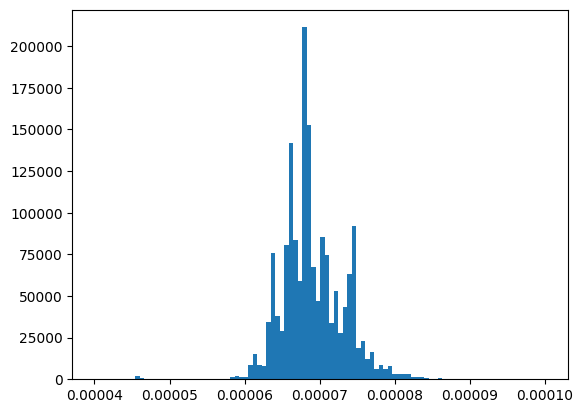

In [107]:
import matplotlib.pyplot as plt
plt.hist(cond.float().view(-1).cpu().numpy(), bins=100, density=True, cumulative=False)

In [108]:
eps = 1e-5
for n,p in network.named_parameters():
    if "proj" in n:
        print(n, ((p.data.abs()> eps).sum()/p.numel()).item())

self_attn.q_proj.weight 0.5015419125556946
self_attn.k_proj.weight 0.6593623161315918
self_attn.v_proj.weight 0.7539083957672119
self_attn.o_proj.weight 0.7312104105949402
mlp.gate_proj.weight 0.7392593622207642
mlp.up_proj.weight 0.744057834148407
mlp.down_proj.weight 0.8082835078239441


In [109]:
param_masks= {}

In [110]:
for g_nnz, g in zip(groups_nnz,groups):
    # grouped_block_norms = g.grouped_block_norms(None)
    # indices = torch.topk(grouped_block_norms,k=g_nnz, dim=-1)[1]
    # grouped_mask = torch.zeros_like(grouped_block_norms).bool()
    # grouped_mask.scatter_(-1, indices, True)

    # m = unmerge_even_dims(grouped_mask.view(g._grid_shape + (grouped_mask.shape[-1],)), g.group_shape)

    # m = m.view(g.block.block_grid_shape).contiguous()
    # m = g.block.broadcast_block_to_element(m)
    # param_masks[g.block.param] = m
    for b, m in g.get_masks(num_nz=g_nnz).items():
        param_masks[b.param] = m

In [111]:
for p,m in param_masks.items():
    print(p.shape, m.sum()/m.numel())

torch.Size([4096, 4096]) tensor(0.5000, device='cuda:0')
torch.Size([1024, 4096]) tensor(0.5000, device='cuda:0')
torch.Size([1024, 4096]) tensor(0.5000, device='cuda:0')
torch.Size([4096, 4096]) tensor(0.5000, device='cuda:0')
torch.Size([12288, 4096]) tensor(0.5000, device='cuda:0')
torch.Size([12288, 4096]) tensor(0.5000, device='cuda:0')
torch.Size([4096, 12288]) tensor(0.5000, device='cuda:0')


In [131]:
network.load_state_dict(deepcopy(original_weights))

<All keys matched successfully>

In [112]:
for p,m in param_masks.items():
    p.data.mul_(m)

In [113]:
import torch.nn.utils.prune as prune

# for layer_name, layer in network.self_attn.named_children():
#     if isinstance(layer, nn.Linear):
#         # mask = (layer.weight.data.abs() > 0)
#         if layer.weight in param_masks:
#             print(layer_name)
#             mask = param_masks[layer.weight]
#             prune.custom_from_mask(layer, 'weight', mask)

for layer_name, layer in network.named_modules():
    if isinstance(layer, nn.Linear):
        if layer.weight in param_masks:
            print(layer_name)
            mask = param_masks[layer.weight]
            prune.custom_from_mask(layer, 'weight', mask)

self_attn.q_proj
self_attn.k_proj
self_attn.v_proj
self_attn.o_proj
mlp.gate_proj
mlp.up_proj
mlp.down_proj


In [107]:
# for layer_name, layer in network.self_attn.named_children():
#     if isinstance(layer, nn.Linear):
#         print(layer_name)
#         try:
#             prune.remove(layer, 'weight')
#         except:
#             pass

for layer_name, layer in network.named_modules():
    if isinstance(layer, nn.Linear):
        print(layer_name)
        try:
            prune.remove(layer, 'weight')
        except:
            pass

self_attn.q_proj
self_attn.k_proj
self_attn.v_proj
self_attn.o_proj
mlp.gate_proj
mlp.up_proj
mlp.down_proj


In [114]:
optimizer = AdamW(
    network.parameters(), lr=5e-5, weight_decay=1e-3, betas=(0.95, 0.999)
)


In [115]:
for epoch in range(epochs):
    pbar = tqdm(np.random.permutation(len(layer_inputs)), desc=f"Epoch {epoch + 1}/{epochs}")
    total_loss = 0.0
    num_batches = 0
    with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
        for idx in pbar:
            num_batches += 1

            model_inputs = transfer_to_device(layer_inputs[idx], network.device)
            target = transfer_to_device(layer_targets[idx],network.device)

            pred = network(*model_inputs["args"], **model_inputs["kwargs"])
            pred,target = pred[0], target[0]

            # target = transfer_to_device(layer_targets[idx],network.device)[0]
            # pred = network(
            #     # model_inputs["args"][0],
            #       **model_inputs["kwargs"]
            # )[0]

            loss = criterion(pred, target)
            optimizer.zero_grad()
            loss.backward()
            # clip_grad_norm_(network.parameters(), max_norm=1.0)

            optimizer.step()
            # for g in groups:
            #     g.hard_threshold(num_nz=target_nnz)

            total_loss += loss.item()
            

            pbar.set_postfix(loss=f"{total_loss / num_batches:e}")
            #, density = np.mean([g.nnz()/g.numel for g in groups]))

        # for n,p in network.named_parameters():
        # for layer in 
        #     if "proj" in n:
        #         print(n,o ((p.data.abs()> 1e-12).sum()/p.numel()).item())

        for layer_name, layer in prune_layers.items():
            if isinstance(layer, nn.Linear):
                p=layer.weight
                print(layer_name, ((p.data.abs()> 1e-12).sum()/p.numel()).item())


Epoch 1/10: 100%|██████████| 1024/1024 [00:56<00:00, 17.98it/s, loss=1.765095e-03]


self_attn.q_proj 0.5
self_attn.k_proj 0.5
self_attn.v_proj 0.5
self_attn.o_proj 0.5
mlp.gate_proj 0.5
mlp.up_proj 0.5
mlp.down_proj 0.5


Epoch 2/10: 100%|██████████| 1024/1024 [00:56<00:00, 18.02it/s, loss=1.729883e-03]


self_attn.q_proj 0.5
self_attn.k_proj 0.5
self_attn.v_proj 0.5
self_attn.o_proj 0.5
mlp.gate_proj 0.5
mlp.up_proj 0.5
mlp.down_proj 0.5


Epoch 3/10: 100%|██████████| 1024/1024 [00:56<00:00, 18.10it/s, loss=1.721639e-03]


self_attn.q_proj 0.5
self_attn.k_proj 0.5
self_attn.v_proj 0.5
self_attn.o_proj 0.5
mlp.gate_proj 0.5
mlp.up_proj 0.5
mlp.down_proj 0.5


Epoch 4/10:  69%|██████▉   | 710/1024 [00:39<00:17, 18.07it/s, loss=1.723835e-03]


KeyboardInterrupt: 

In [116]:

with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
    with torch.no_grad():
        pbar = tqdm(range(len(layer_inputs)), desc=f"Eval initial loss")
        total_loss = 0.0
        total_mse = 0.0
        num_batches = 0
        for idx in pbar:
            model_inputs = transfer_to_device(layer_inputs[idx], network.device)
            target = transfer_to_device(layer_targets[idx],network.device)
            # target = transfer_to_device(layer_targets[idx],network.device)[0]
            num_batches += 1
            pred = network(
                *model_inputs["args"],
                **model_inputs["kwargs"]
            )
            pred,target = pred[0], target[0]
            total_loss += criterion(pred, target).item()
            total_mse += criterion(torch.zeros_like(target), target).item()
            pbar.set_postfix(
                loss=f"{total_loss / num_batches:e}",
                mse=f"{total_mse / num_batches:e}",
                density=np.mean([g.nnz() / g.numel() for g in groups]),
            )

Eval initial loss: 100%|██████████| 1024/1024 [00:24<00:00, 41.90it/s, density=0.5, loss=1.716860e-03, mse=3.029144e-02]


In [117]:
for layer_name, layer in network.named_modules():
    if isinstance(layer, nn.Linear):
        p=layer.weight
        print(layer_name, ((p.data.abs()> 1e-12).sum()/p.numel()).item())

self_attn.q_proj 0.5
self_attn.k_proj 0.5
self_attn.v_proj 0.5
self_attn.o_proj 0.5
mlp.gate_proj 0.5
mlp.up_proj 0.5
mlp.down_proj 0.5


In [617]:
to_keep = network.mlp.down_proj.weight.data.abs().sum(0) > 0

In [620]:
network.mlp.down_proj.weight.data = network.mlp.down_proj.weight.data[:,to_keep]

In [622]:
network.mlp.gate_proj.weight.data = network.mlp.gate_proj.weight.data[to_keep]

In [625]:
network.mlp.up_proj.weight.data = network.mlp.up_proj.weight.data[to_keep,:]

In [129]:
for n,p in network.named_parameters():
    if "proj" in n:
        print(n, p.shape)

q_proj.weight torch.Size([4096, 4096])
k_proj.weight torch.Size([1024, 4096])
v_proj.weight torch.Size([1024, 4096])
o_proj.weight torch.Size([4096, 4096])


In [130]:
# if True:
if False:
    from pathlib import Path
    layer_ckpt_path =  Path(f"/buckets/checkpoints/{model_name}_decoder_{layer_idx}.cpt")
    layer_ckpt_path.parent.mkdir(parents=True,exist_ok=True)
    print(layer_ckpt_path)

    torch.save(network.state_dict(),layer_ckpt_path)

In [255]:
# for g in groups:
#     conditioners = {}
#     psis = {}
#     block = g.block

#     gradient, lr, conditioner = proxy.get_info(block.param)
#     psi = (gradient - alpha * block.param.data).abs()
#     lambds[g].mul_(beta).add_(
#         (1 - beta) * g.kth_largest({block: psi}, num_nz=target_nnz)
#     )
#     g.soft_threshold((lambds[g]) * lr, conditioners={block: conditioner})

In [118]:
import matplotlib.pyplot as plt

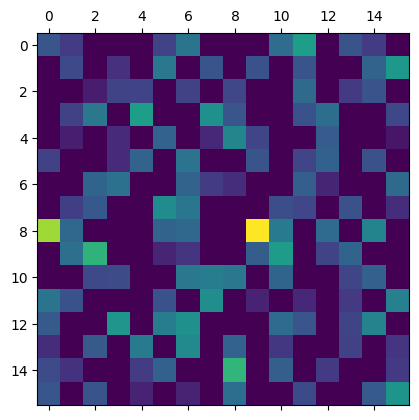

In [119]:
# plt.matshow(network.mlp.down_proj.weight.data.cpu()[:16][:,:16].float().abs())
plt.matshow(network.self_attn.o_proj.weight.data.cpu()[:16][:,:16].float().abs())

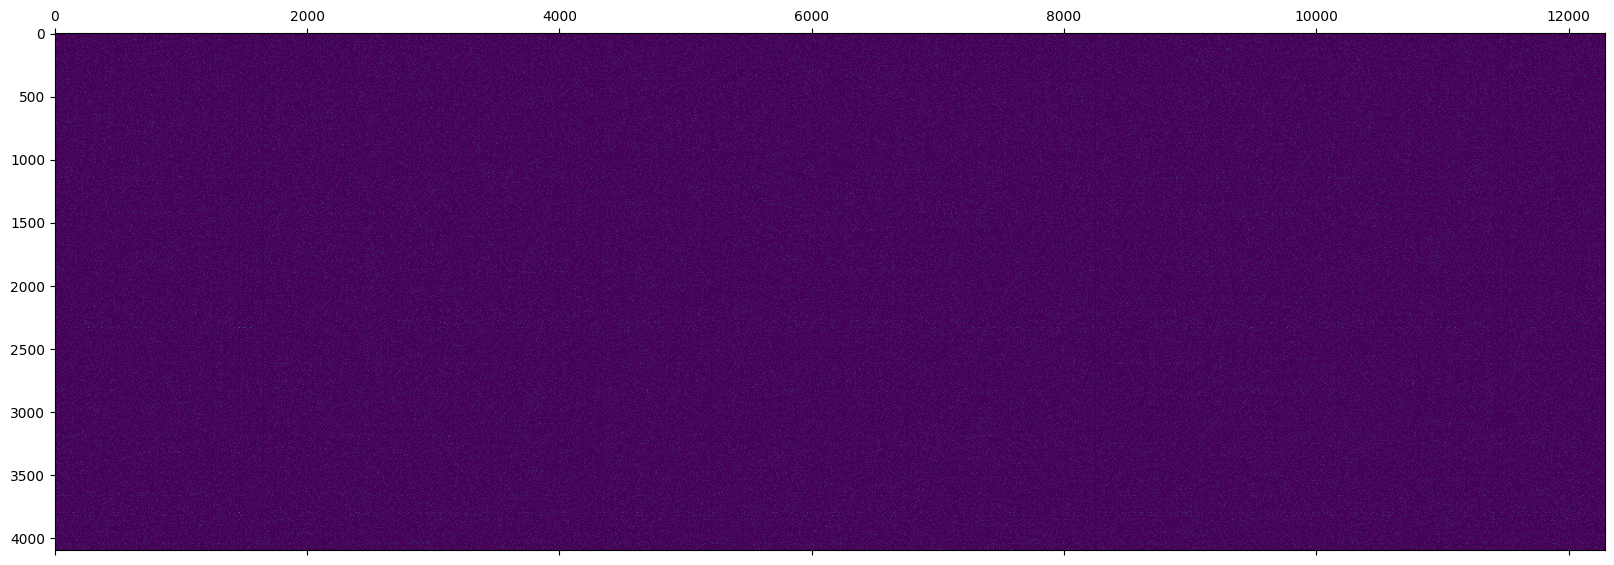

In [120]:
plt.figure(figsize=(20,20))
plt.matshow(network.mlp.down_proj.weight.data.cpu().float().abs(),fignum=1)
plt.show()

In [172]:
# student.model.layers[0].self_attn.q_proj.weight.grad*1e-35

In [173]:
for n,p in student.named_parameters():
    if "proj" in n:
        print(n, ((p.data.abs()> 1e-12).sum()/p.numel()).item())

model.layers.0.self_attn.q_proj.weight 1.0
model.layers.0.self_attn.k_proj.weight 1.0
model.layers.0.self_attn.v_proj.weight 1.0
model.layers.0.self_attn.o_proj.weight 1.0
model.layers.0.mlp.gate_proj.weight 1.0
model.layers.0.mlp.up_proj.weight 1.0
model.layers.0.mlp.down_proj.weight 1.0
model.layers.1.self_attn.q_proj.weight 0.5
model.layers.1.self_attn.k_proj.weight 0.5
model.layers.1.self_attn.v_proj.weight 0.5
model.layers.1.self_attn.o_proj.weight 0.5
model.layers.1.mlp.gate_proj.weight 0.5
model.layers.1.mlp.up_proj.weight 0.5
model.layers.1.mlp.down_proj.weight 0.5
model.layers.2.self_attn.q_proj.weight 1.0
model.layers.2.self_attn.k_proj.weight 1.0
model.layers.2.self_attn.v_proj.weight 1.0
model.layers.2.self_attn.o_proj.weight 1.0
model.layers.2.mlp.gate_proj.weight 1.0
model.layers.2.mlp.up_proj.weight 1.0
model.layers.2.mlp.down_proj.weight 1.0
model.layers.3.self_attn.q_proj.weight 1.0
model.layers.3.self_attn.k_proj.weight 1.0
model.layers.3.self_attn.v_proj.weight 1.0
m

In [ ]:
prompt = "Give me a brief explanation of gravity in simple terms."
messages_think = [
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages_think,
    tokenize=False,
    add_generation_prompt=True,
)
model_inputs = tokenizer([text], return_tensors="pt").to(teacher.device)

# Generate the output
generated_ids = teacher.generate(**model_inputs, max_new_tokens=2048)

# Get and decode the output
output_ids = generated_ids[0][len(model_inputs.input_ids[0]) :]
print(tokenizer.decode(output_ids, skip_special_tokens=True))

<think>
Okay, the user wants a brief explanation of gravity in simple terms. Let me start by recalling what I know about gravity. It's a force that attracts objects with mass towards each other. But how do I explain that simply?

Maybe start with the basic idea that everything with mass pulls on everything else. But I should avoid jargon. Use everyday examples, like why we stay on the ground. Also, mention that the more mass an object has, the stronger its gravitational pull. But I need to keep it short. Should I mention Newton's law of universal gravitation? Maybe not too detailed. Also, perhaps touch on Einstein's theory of relativity briefly, but since it's simple terms, maybe just stick to Newton's explanation. Wait, the user said "simple terms," so maybe just the basics. Let me check if there's anything else. Oh, the concept of gravity as a force that keeps planets in orbit. Yeah, that's a good point. But keep it concise. Let me structure it: start with gravity as a force, mention

In [138]:
prompt = "Give me a brief explanation of gravity in simple terms."
messages_think = [
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages_think,
    tokenize=False,
    add_generation_prompt=True,
)
model_inputs = tokenizer([text], return_tensors="pt").to(student.device)

# Generate the output
generated_ids = student.generate(**model_inputs, max_new_tokens=2048)

# Get and decode the output
output_ids = generated_ids[0][len(model_inputs.input_ids[0]) :]
print(tokenizer.decode(output_ids, skip_special_tokens=True))

<think>
Okay, the user wants a brief explanation of gravity in simple terms. Let me start by recalling what I know about gravity. Gravity is a force that attracts objects with mass towards each other. But how to explain that simply?

Maybe start with the basic idea that everything with mass pulls on other things. But I should avoid jargon. Use everyday examples. Like apples falling from trees or planets orbiting the sun. Wait, but maybe the user is looking for something even more basic. Maybe mention that it's what keeps us on the ground. But I need to make sure it's clear and not too technical.

Also, Newton's law of universal gravitation comes to mind, but that might be too complex. Maybe just mention that the more mass an object has, the stronger its gravitational pull. And the closer two objects are, the stronger the pull. But keep it simple. Maybe use the example of Earth pulling us down, and the moon's gravity keeping the tides. But should I mention Einstein's theory of relativit

In [174]:
# optimizer.zero_grad(set_to_none=True)
torch.cuda.empty_cache()

In [121]:
from lm_eval.tasks import TaskManager
from lm_eval.models import huggingface
from lm_eval.evaluator import simple_evaluate


hf_model = huggingface.HFLM(student, tokenizer=tokenizer)

task_manager = TaskManager()

with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
    with torch.no_grad():

        results = simple_evaluate(
            model=hf_model,
            tasks=["wikitext"],
            num_fewshot=0,
            task_manager=task_manager,
            log_samples=False,
            batch_size=2,
            # delete_requests_cache=True,
        )


print(results["results"])
del results
torch.cuda.empty_cache()

`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
[Task: wikitext] metric word_perplexity is defined, but aggregation is not. using default aggregation=weighted_perplexity
[Task: wikitext] metric word_perplexity is defined, but higher_is_better is not. using default higher_is_better=False
[Task: wikitext] metric byte_perplexity is defined, but aggregation is not. using default aggregation=weighted_perplexity
[Task: wikitext] metric byte_perplexity is defined, but higher_is_better is not. using default higher_is_better=False
[Task: wikitext] metric bits_per_byte is defined, but aggregation is not. using default aggregation=bits_per_byte
[Task: wikitext] metric bits_per_byte is defined, but higher_is_better is not. u

{'wikitext': {'alias': 'wikitext', 'word_perplexity,none': 12.395593424523499, 'word_perplexity_stderr,none': 'N/A', 'byte_perplexity,none': 1.6012032183289524, 'byte_perplexity_stderr,none': 'N/A', 'bits_per_byte,none': 0.6791564205773806, 'bits_per_byte_stderr,none': 'N/A'}}


In [ ]:
res_0 = {
    "alias": "wikitext",
    "word_perplexity,none": 12.498512406768052,
    "word_perplexity_stderr,none": "N/A",
    "byte_perplexity,none": 1.603681022058534,
    "byte_perplexity_stderr,none": "N/A",
    "bits_per_byte,none": 0.6813872130785015,
    "bits_per_byte_stderr,none": "N/A",
}
# res_0_24: {'wikitext': {'alias': 'wikitext', 'word_perplexity,none': 12.43919975097054, 'word_perplexity_stderr,none': 'N/A', 'byte_perplexity,none': 1.6022550873779982, 'byte_perplexity_stderr,none': 'N/A', 'bits_per_byte,none': 0.6801038506173205, 'bits_per_byte_stderr,none': 'N/A'}}
# res_0_o_proj_0p8: {'wikitext': {'alias': 'wikitext', 'word_perplexity,none': 12.32192808501638, 'word_perplexity_stderr,none': 'N/A', 'byte_perplexity,none': 1.5994194140459086, 'byte_perplexity_stderr,none': 'N/A', 'bits_per_byte,none': 0.6775483048104739, 'bits_per_byte_stderr,none': 'N/A'}}

res_1_no_0 = {
    "alias": "wikitext",
    "word_perplexity,none": 12.261166959059729,
    "word_perplexity_stderr,none": "N/A",
    "byte_perplexity,none": 1.5979415482761852,
    "byte_perplexity_stderr,none": "N/A",
    "bits_per_byte,none": 0.6762146363294731,
    "bits_per_byte_stderr,none": "N/A",
}
# res_1_no_0_24: {'wikitext': {'alias': 'wikitext', 'word_perplexity,none': 12.238224324085651, 'word_perplexity_stderr,none': 'N/A', 'byte_perplexity,none': 1.5973819760168617, 'byte_perplexity_stderr,none': 'N/A', 'bits_per_byte,none': 0.6757093403081719, 'bits_per_byte_stderr,none': 'N/A'}}

original = {
    "alias": "wikitext",
    "word_perplexity,none": 12.21292061236587,
    "word_perplexity_stderr,none": "N/A",
    "byte_perplexity,none": 1.5967638270712277,
    "byte_perplexity_stderr,none": "N/A",
    "bits_per_byte,none": 0.675150943488172,
    "bits_per_byte_stderr,none": "N/A",
}


In [ ]:
task_manager = TaskManager()
with torch.no_grad():


    results = simple_evaluate(
        model=hf_model,
        tasks=["hellaswag"],
        task_manager=task_manager,
        log_samples=False,
        batch_size=2,
        # delete_requests_cache=True,
    )


print(results["results"])
del results
torch.cuda.empty_cache()

Running loglikelihood requests: 100%|██████████| 40168/40168 [35:02<00:00, 19.10it/s]


{'hellaswag': {'alias': 'hellaswag', 'acc,none': 0.5686118303126867, 'acc_stderr,none': 0.004942578520987334, 'acc_norm,none': 0.7474606652061342, 'acc_norm_stderr,none': 0.004335809614480291}}


In [ ]:
from lm_eval.tasks import TaskManager
from lm_eval.models import huggingface
from lm_eval.evaluator import simple_evaluate


hf_model = huggingface.HFLM(teacher, tokenizer=tokenizer)

task_manager = TaskManager()
with torch.no_grad():


    results = simple_evaluate(
        model=hf_model,
        tasks=["wikitext"],
        num_fewshot=0,
        task_manager=task_manager,
        log_samples=False,
        # delete_requests_cache=True,
    )


print(results["results"])
del results
torch.cuda.empty_cache()

`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
[Task: wikitext] metric word_perplexity is defined, but aggregation is not. using default aggregation=weighted_perplexity
[Task: wikitext] metric word_perplexity is defined, but higher_is_better is not. using default higher_is_better=False
[Task: wikitext] metric byte_perplexity is defined, but aggregation is not. using default aggregation=weighted_perplexity
[Task: wikitext] metric byte_perplexity is defined, but higher_is_better is not. using default higher_is_better=False
[Task: wikitext] metric bits_per_byte is defined, but aggregation is not. using default aggregation=bits_per_byte
[Task: wikitext] metric bits_per_byte is defined, but higher_is_better is not. u

{'wikitext': {'alias': 'wikitext', 'word_perplexity,none': 12.21292061236587, 'word_perplexity_stderr,none': 'N/A', 'byte_perplexity,none': 1.5967638270712277, 'byte_perplexity_stderr,none': 'N/A', 'bits_per_byte,none': 0.675150943488172, 'bits_per_byte_stderr,none': 'N/A'}}


In [ ]:
for p_s, p_t in zip(student.parameters(), teacher.parameters()):
    mask = (p_s.data.abs()>0)
    p_s.data.copy_(p_t.data)
    p_s.data.mul_(mask)

In [ ]:
for g in groups:
    print(g.nnz()/g.numel)

0.8972702026367188
0.9430499076843262
0.9720439910888672
0.9614696502685547
0.8927122751871744
0.9104450543721517
0.9329125881195068
0.867070198059082
0.9119582176208496
0.947108268737793
0.9419543743133545
0.815058708190918
0.8814824422200521
0.8743852774302164
0.8565797805786133
0.9032082557678223
0.9477190971374512
0.9393625259399414
0.8835160732269287
0.999999205271403
0.9999996026357015
0.9999997615814209
1.0
0.9999995231628418
0.9999997615814209
0.9999992847442627
0.9999996026357015
0.9999997615814209
1.0
1.0
0.9999990463256836
1.0
0.9999994436899821
0.9999998410542806
0.9999997615814209
0.9999992847442627
1.0
1.0
0.9999992847442627
0.9999998410542806
0.9999998410542806
0.9999998410542806
1.0
1.0
1.0
0.9999997615814209
0.9999998410542806
0.9999996026357015
0.9999997615814209
0.9999997615814209
0.9999995231628418
1.0
1.0
0.9999998410542806
0.9999993642171224
0.9999996821085612
0.9999997615814209
0.9999995231628418
1.0
0.9999995231628418
0.9999996821085612
0.9999999205271403
0.9999

In [ ]:
with torch.no_grad():
    pbar = tqdm(range(len(tokenized_inputs)), desc=f"Epoch {epoch + 1}/{epochs}")
    total_loss = 0.0
    num_batches = 0
    for idx in pbar:
        model_inputs = tokenized_inputs[idx]
        num_batches += 1
        target = target_logits[idx].to(student.device)
        target = target.view(-1, target.shape[-1])
        pred = student(**model_inputs.to(student.device), labels=None).logits
        pred = pred.view(-1, pred.shape[-1])


        loss = criterion(pred, target)
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{total_loss / num_batches:.6f}", density = np.mean([g.nnz()/g.numel for g in groups]))

Epoch 2/10: 100%|██████████| 128/128 [00:10<00:00, 11.78it/s, density=0.5, loss=9.617188]
